In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from ema_workbench.analysis import pairs_plotting
from ema_workbench.analysis import feature_scoring
from tqdm import tqdm

from sklearn.preprocessing import StandardScaler, LabelEncoder

import warnings
from sklearn import tree
from pprint import pprint 
import graphviz
import sklearn
import dtreeviz

import os
import sys
sys.path.insert(0, '..')

from archspace import CQRS, ArchSpace
from archspace import show_pairplot, show_feature_scores, show_outcome_distributions, show_tradeoff_distribution
from archspace import show_quality_attribute_space2D, show_configuration_space2D

In [2]:
# from os import listdir
# from os.path import isfile, join

# mypath = "./separated_HW/additional_results"
# # mypath = "./separated_SW/additional_results"
# onlyfiles = [f for f in listdir(mypath) if isfile(join(mypath, f))]

# list_dfs = []
# for f in onlyfiles:
#     df = pd.read_csv(mypath + "/" + f)
#     print(f, df.shape)
#     list_dfs.append(df) 
# df = pd.concat(list_dfs, axis=0, ignore_index=True)
# df.to_csv("./separated_HW/sep_phy_new.csv", index=False)
# # df.to_csv("./separated_SW/sep_mod_new.csv", index=False)
# df

In [3]:
my_space = CQRS()
my_space.create_model('cqrs')

# experiments_df, outcomes_df = my_space.load_results('./separated_HW/sep_phy.csv', kind='hw')
# experiments_df, outcomes_df = my_space.load_results('./separated_SW/sep_mod.csv', kind='sw')
experiments_df, outcomes_df = my_space.load_results('./separated_HW/sep_phy_new.csv', kind='hw')
experiments_df, outcomes_df = my_space.load_results('./separated_SW/sep_mod_new.csv', kind='sw')

print(len(my_space.get_configurations()), "configurations")

(324, 33)
(324, 14)
initial size: (324, 12)
(324, 32)
(324, 13)
appended size: (324, 12)
final size: (648, 12)
2 configurations


In [4]:
experiments_df

,scenario,N_read,N_write,r_Z_read,r_Z_write,C_DB_read,r_DB_read,C_DB_write,r_DB_write,C_DB,policy,model
0,0,90,10,0.1,0.002439,1,0.142857,1,0.027778,2,hw,cqrs
1,1,90,10,0.1,0.002632,1,0.142857,1,0.027778,2,hw,cqrs
2,2,90,10,0.1,0.002273,1,0.142857,1,0.027778,2,hw,cqrs
3,3,90,10,0.1,0.002128,1,0.142857,1,0.027778,2,hw,cqrs
4,4,90,10,0.1,0.002381,1,0.142857,1,0.027778,2,hw,cqrs
...,...,...,...,...,...,...,...,...,...,...,...,...
643,319,90,10,0.1,0.001064,1,0.333333,1,0.027778,1,sw,cqrs
644,320,90,10,0.1,0.001031,1,0.333333,1,0.027778,1,sw,cqrs
645,321,90,10,0.1,0.001099,1,0.333333,1,0.027778,1,sw,cqrs
646,322,90,10,0.1,0.001000,1,0.333333,1,0.027778,1,sw,cqrs


In [5]:
experiments_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 648 entries, 0 to 647
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   scenario    648 non-null    int64  
 1   N_read      648 non-null    int64  
 2   N_write     648 non-null    int64  
 3   r_Z_read    648 non-null    float64
 4   r_Z_write   648 non-null    float64
 5   C_DB_read   648 non-null    int64  
 6   r_DB_read   648 non-null    float64
 7   C_DB_write  648 non-null    int64  
 8   r_DB_write  648 non-null    float64
 9   C_DB        648 non-null    int64  
 10  policy      648 non-null    object 
 11  model       648 non-null    object 
dtypes: float64(4), int64(6), object(2)
memory usage: 60.9+ KB


/Users/adiazpace/opt/anaconda3/envs/perfmodels/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
OMP: Info #270: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


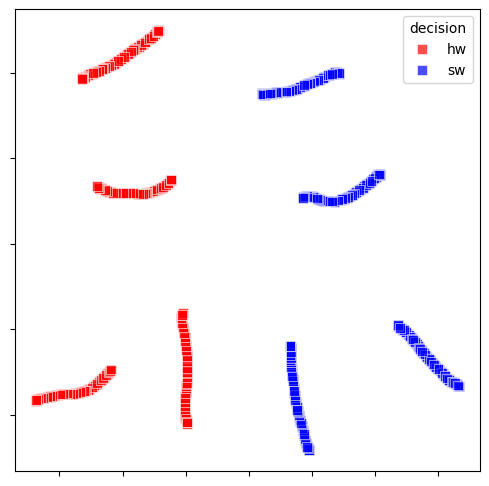

In [6]:
color_key = {'hw': 'red',
             'sw': 'blue'}
embeddings_df = show_configuration_space2D(experiments_df, color_key=color_key, alpha=0.7)

In [7]:
outcomes_df

,response_time,utilization
0,623.357807,0.788651
1,657.074243,0.775553
2,610.452155,0.805374
3,598.339975,0.794788
4,606.345257,0.808493
...,...,...
643,400.166379,0.500181
644,395.435435,0.500419
645,395.436904,0.499926
646,388.136385,0.502448


In [8]:
outcomes_df.describe()

,response_time,utilization
count,648.000000,648.000000
mean,659.784585,0.601964
std,355.493788,0.110694
min,283.228874,0.493556
25%,429.982207,0.500460
50%,604.379940,0.510975
75%,871.257721,0.712609
max,3604.255148,0.808493


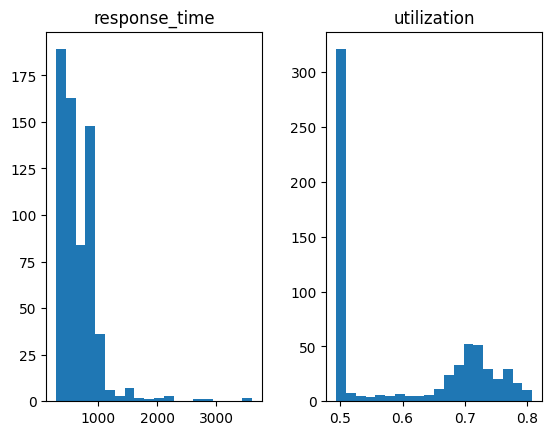

In [9]:
# outcomes
outcomes_df.hist(bins=20, grid=False)
plt.show()

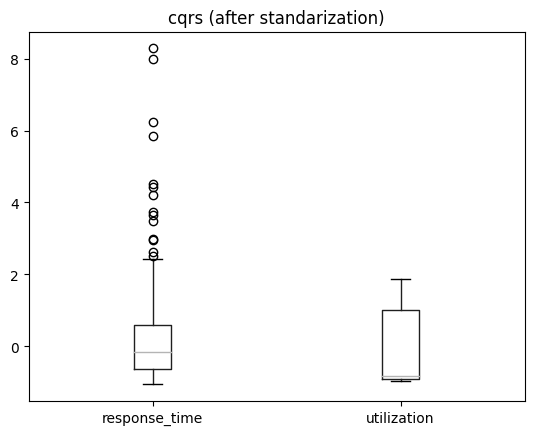

In [10]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(outcomes_df)
scaled_df = pd.DataFrame(scaled_data, columns=outcomes_df.columns)
scaled_df.boxplot(grid=False)
plt.title('cqrs (after standarization)')
plt.show()

# TODO: Probably I should remove outliers for response time

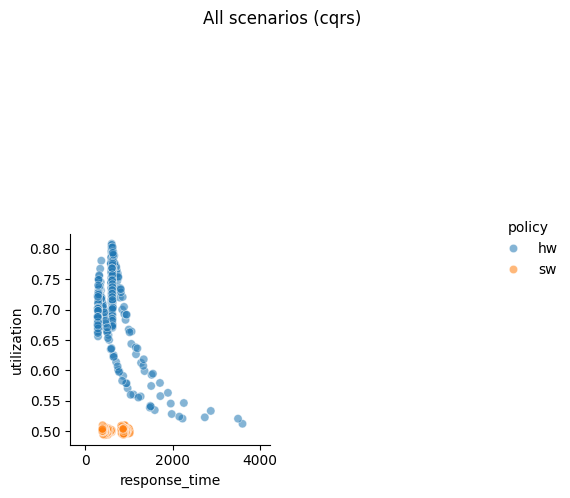

In [11]:
# show_pairplot(experiments_df, outcomes, title='All scenarios (cqrs)', kind='sns')
show_pairplot(my_space, title='All scenarios (cqrs)', kind='sns', group='policy', legend=True) #, filename=None)

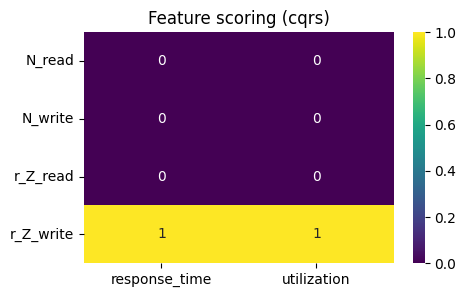

,response_time,utilization
0,,
N_read,0.0,0.0
N_write,0.0,0.0
r_Z_read,0.0,0.0
r_Z_write,1.0,1.0


In [12]:
policy_size = (5,3)
filter_params = ['N_read', 'N_write', 'r_Z_read', 'r_Z_write']
fs = show_feature_scores(my_space, title='Feature scoring (cqrs)', size=policy_size, parameters=filter_params) #, filename=None)  
fs

In [13]:
my_policies = my_space.get_configurations()
my_policies

['hw', 'sw']

Instances for configuration: (324, 8)


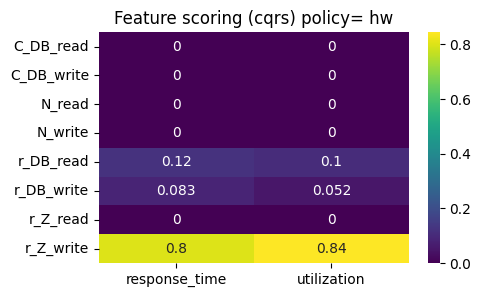

,response_time,utilization
0,,
C_DB_read,0.000000,0.000000
C_DB_write,0.000000,0.000000
N_read,0.000000,0.000000
N_write,0.000000,0.000000
r_DB_read,0.119932,0.104627
r_DB_write,0.082599,0.051780
r_Z_read,0.000000,0.000000
r_Z_write,0.797469,0.843593


In [14]:
show_feature_scores(my_space, title='Feature scoring (cqrs)', policy=my_policies[0], size=policy_size) #, filename=None)

Instances for configuration: (324, 7)


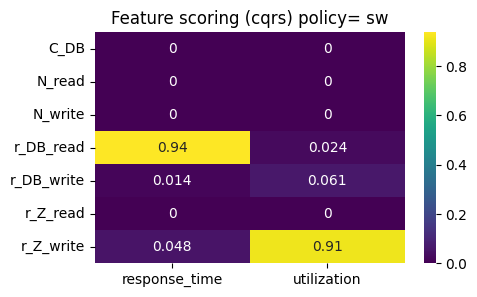

,response_time,utilization
0,,
C_DB,0.000000,0.000000
N_read,0.000000,0.000000
N_write,0.000000,0.000000
r_DB_read,0.938030,0.023982
r_DB_write,0.013987,0.061358
r_Z_read,0.000000,0.000000
r_Z_write,0.047983,0.914660


In [15]:
show_feature_scores(my_space, title='Feature scoring (cqrs)', policy=my_policies[1], size=policy_size) #, filename=None)

Absolute ranges: [(283.0, 3605.0), (0.0, 1.0)]
response_time [282.9, 1390.2999999999997, 2497.7, 3605.1]
utilization [-0.1, 0.30000000000000004, 0.7000000000000002, 1.1]


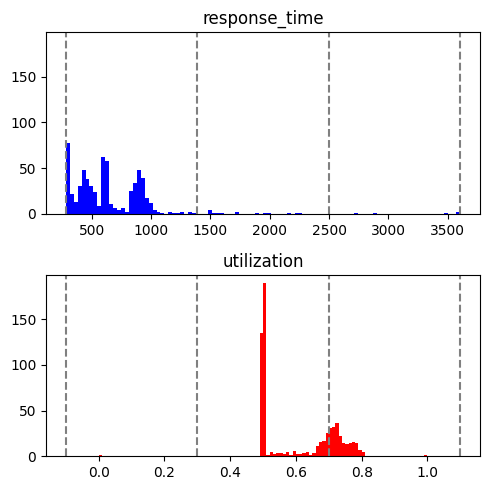

{'response_time': [282.9, 1390.2999999999997, 2497.7, 3605.1],
 'utilization': [-0.1, 0.30000000000000004, 0.7000000000000002, 1.1]}

In [16]:
MIN_RESPONSE_TIME, MAX_RESPONSE_TIME = (283.0, 3605.0)
# MIN_READ_RESPONSE_TIME, MAX_READ_RESPONSE_TIME = (450, 5260)
# MIN_WRITE_RESPONSE_TIME, MAX_WRITE_RESPONSE_TIME = (408, 1619)
# MIN_UTILIZATION, MAX_UTILIZATION = (0.98, 1.55)
MIN_UTILIZATION, MAX_UTILIZATION = (0.0, 1.0)

# MIN_MAX_RANGES = [(MIN_RESPONSE_TIME, MAX_RESPONSE_TIME), (MIN_READ_RESPONSE_TIME, MAX_READ_RESPONSE_TIME), 
#                   (MIN_WRITE_RESPONSE_TIME, MAX_WRITE_RESPONSE_TIME), (MIN_UTILIZATION, MAX_UTILIZATION)]
MIN_MAX_RANGES = [(MIN_RESPONSE_TIME, MAX_RESPONSE_TIME), (MIN_UTILIZATION, MAX_UTILIZATION)]
print('Absolute ranges:', MIN_MAX_RANGES)

show_outcome_distributions(my_space, mins_maxs=MIN_MAX_RANGES, size=(5,5))

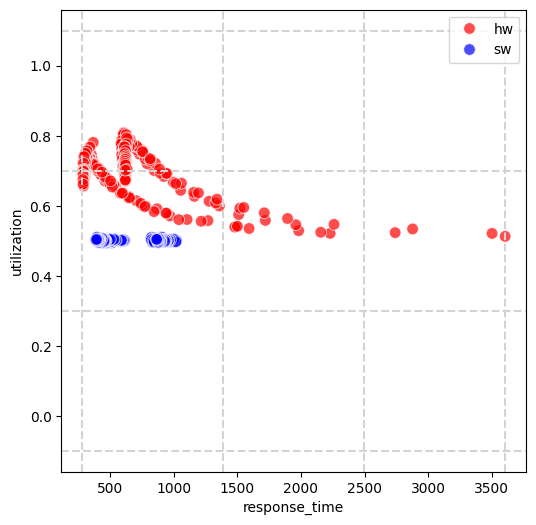

In [17]:
df = outcomes_df.copy()
df['decision'] = experiments_df['policy']
show_quality_attribute_space2D(df, MIN_MAX_RANGES, alpha=0.7,color_key=color_key)

In [18]:
print("Configurations:", my_space.get_configurations())

Configurations: ['hw', 'sw']


Experiments for policy sw : 324
response_time [282.9, 1390.2999999999997, 2497.7, 3605.1]
utilization [-0.1, 0.30000000000000004, 0.7000000000000002, 1.1]


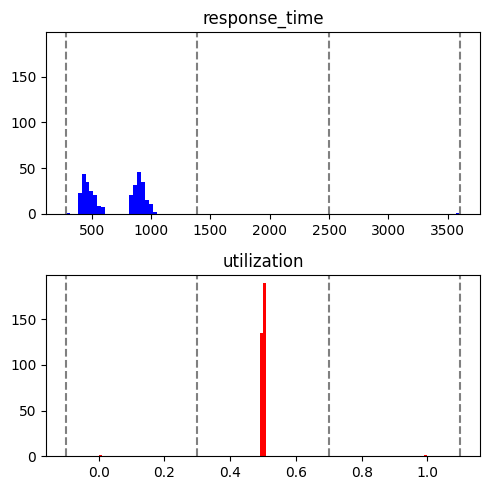

{'response_time': [282.9, 1390.2999999999997, 2497.7, 3605.1],
 'utilization': [-0.1, 0.30000000000000004, 0.7000000000000002, 1.1]}

In [19]:
config = 'sw'
show_outcome_distributions(my_space, mins_maxs=MIN_MAX_RANGES, size=(5,5), policy=config)

Experiments for policy hw : 324
response_time [282.9, 1390.2999999999997, 2497.7, 3605.1]
utilization [-0.1, 0.30000000000000004, 0.7000000000000002, 1.1]


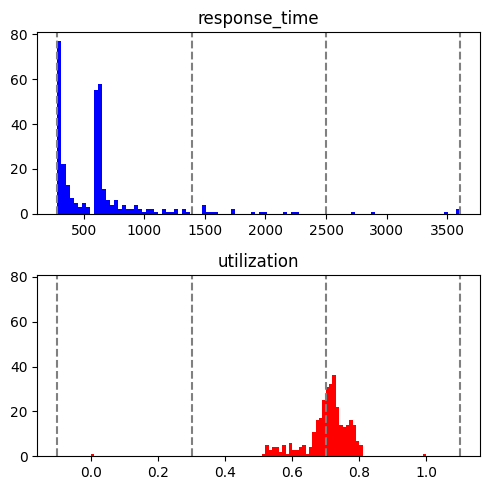

{'response_time': [282.9, 1390.2999999999997, 2497.7, 3605.1],
 'utilization': [-0.1, 0.30000000000000004, 0.7000000000000002, 1.1]}

In [20]:
config = 'hw'
show_outcome_distributions(my_space, mins_maxs=MIN_MAX_RANGES, size=(5,5), policy=config)

In [21]:
_ = my_space.discretize_outcomes(mins_maxs=MIN_MAX_RANGES)
print("Experiments:", experiments_df.shape)

config = "hw"
exp_df, out_df, discrete_out_df = my_space.get_experiment(config)

# print(exp_df.head())
# print(out_df.head())
# print(discrete_exp_df)
print(my_space.available_tradeoffs_)
print("Tradeoffs for ", config,"-->", CQRS.get_tradeoffs(discrete_out_df))
discrete_out_df.head(10)

Experiments: (648, 12)
Counter({'fast,average': 425, 'fast,high': 204, 'average,average': 15, 'slow,average': 4})
Tradeoffs for  hw --> Counter({'fast,high': 204, 'fast,average': 101, 'average,average': 15, 'slow,average': 4})


,response_time,utilization
0,fast,high
1,fast,high
2,fast,high
3,fast,high
4,fast,high
5,fast,high
6,fast,high
7,fast,high
8,fast,high
9,fast,high


In [22]:
my_space.available_tradeoffs_

Counter({'fast,average': 425,
         'fast,high': 204,
         'average,average': 15,
         'slow,average': 4})

In [23]:
X_train, X_test, y_train, y_test = my_space.split_dataset(test_size=0.2, remove_outliers=3)
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(648, 14) 648
Removing outliers ... 3
Instances to remove (outliers): {321, 258, 323, 102, 142, 278, 312, 89, 125, 286}
Instances to remove (not enough tradeoffs): {321, 258, 323, 102, 142, 278, 312, 89, 125, 286}
{'fast,average', 'average,average', 'fast,high'}
(638, 14) 638
(510, 14) (510, 2) (128, 14) (128, 2)


In [24]:
X_train[['response_time', 'utilization']].describe()

,response_time,utilization
count,510.000000,510.000000
mean,624.234090,0.603171
std,256.908170,0.111239
min,283.228874,0.493556
25%,425.898503,0.500427
50%,598.152188,0.508303
75%,857.229495,0.713277
max,1720.512021,0.808493


In [25]:
X_test[['response_time', 'utilization']].describe()

,response_time,utilization
count,128.000000,128.000000
mean,656.061756,0.602655
std,270.704439,0.111427
min,286.415311,0.494189
25%,445.976310,0.500407
50%,620.679170,0.507093
75%,880.319825,0.711629
max,1712.170788,0.794788


In [26]:
my_space.import_dataset(X_train, y_train)

In [27]:
# reference_tradeoff = 'slow,average' #'slow,slow,fast,low'
# # reference_tradeoff = ['fast,low', 'fast,average']
# r1, qat = my_space.compute_robustness([config], reference_tradeoff)
# print("Robustness of single solution", config, "w.r.t tradeoff:", qat, "-->", round(r1*100, 2), "%")
# print()

# list_of_configs = my_space.get_nearest_configurations(config, k=1)
# # list_of_configs = configs_df.values.tolist()
# # print(all(isinstance(elem, list) for elem in list_of_configs), list_of_configs)
# r1, qat = my_space.compute_robustness(list_of_configs, reference_tradeoff) 
# print("Robustness of list of solutions", list_of_configs, "w.r.t tradeoff:", qat, "-->", round(r1*100, 2), "%")
# # print(configs_df)
# print()
# qa_config = 'fast,average' #'fast,fast,fast,average'
# qa_configs = my_space.get_nearest_tradeoffs(qa_config, k=1)
# print("Neighbors of:", qa_configs)
# print()
# qat = my_space.get_nearest_tradeoffs(qa_config, k=2)
# r1, qat = my_space.compute_robustness([config], qa_config)
# print("Robustness of single solution", config, "w.r.t tradeoff:", qat, "-->", round(r1*100, 2), "%")
# r1, qat = my_space.compute_robustness([config], qa_configs[0:2])
# print("Robustness of single solution", config, "w.r.t list of tradeoffs:", qat, "-->", round(r1*100, 2), "%")
# print()

Computing robustness for all configurations...


100%|██████████| 2/2 [00:00<00:00, 28.12it/s]


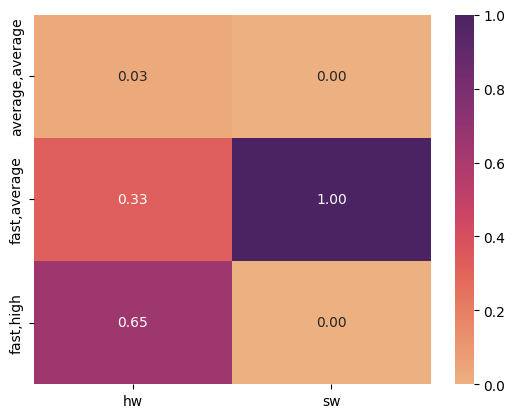

,hw,sw
"average,average",0.027778,0.0
"fast,average",0.325397,1.0
"fast,high",0.646825,0.0


In [28]:
print("Computing robustness for all configurations...")
df = my_space.compute_robustness_matrix()
# df.to_csv('./cqrs_robustness_matrix.csv')

sns.heatmap(df, annot=True, fmt=".2f", cmap='flare')
plt.show()
df

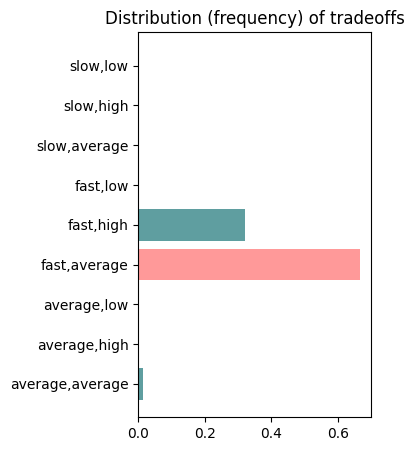

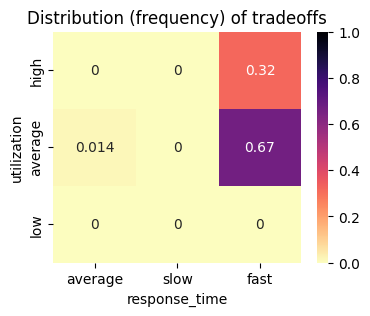

In [29]:
show_tradeoff_distribution(my_space, size=(3,5))
show_tradeoff_distribution(my_space, size=(4,3), in2D=True)

sw Counter({'fast,average': 258})
Instances for configuration: (258, 2)


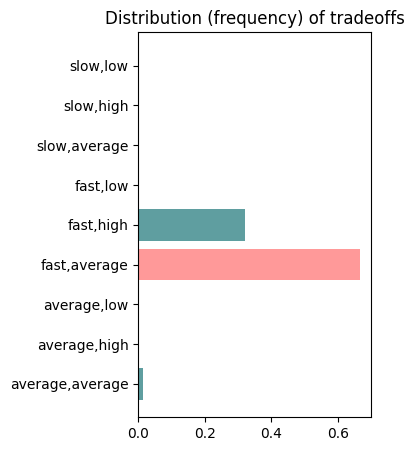

sw Counter({'fast,average': 258})
Instances for configuration: (258, 2)


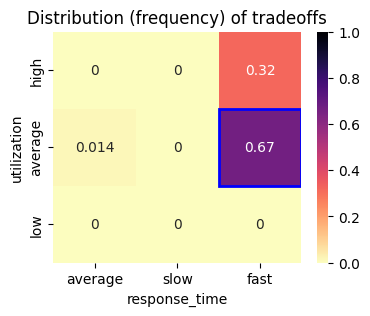

In [30]:
config = 'sw'
show_tradeoff_distribution(my_space, config, size=(3,5))
show_tradeoff_distribution(my_space, config, size=(4,3), in2D=True)

In [31]:
#config = 'sw'
_, _, config_outcomes_df = my_space.get_experiment(config)
# config_outcomes_df

hw Counter({'fast,high': 163, 'fast,average': 82, 'average,average': 7})
Instances for configuration: (252, 2)


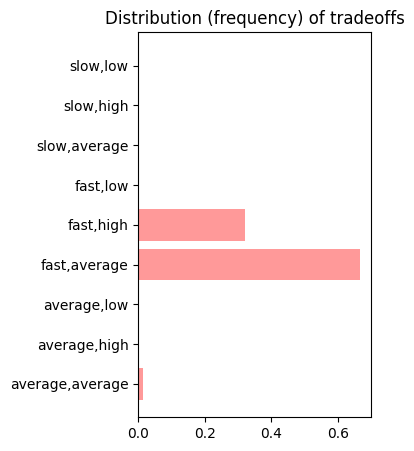

hw Counter({'fast,high': 163, 'fast,average': 82, 'average,average': 7})
Instances for configuration: (252, 2)


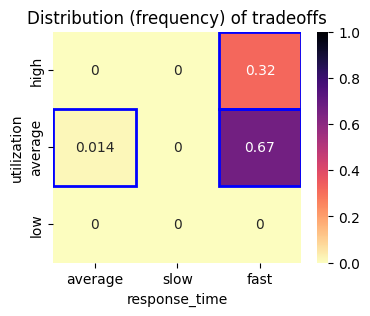

In [32]:
config = 'hw'
show_tradeoff_distribution(my_space, config, size=(3,5))
show_tradeoff_distribution(my_space, config, size=(4,3), in2D=True)

In [33]:
# config = 'hw'
_, _, config_outcomes_df = my_space.get_experiment(config)
# config_outcomes_df

In [34]:
label_values_df = my_space.describe_labels(n_bins=3)
label_values_df

,objective,min,max,label
0,response_time,283.128874,762.289923,fast
1,response_time,762.289923,1241.450972,average
2,response_time,1241.450972,1720.612021,slow
3,utilization,0.393556,0.565202,low
4,utilization,0.565202,0.736847,average
5,utilization,0.736847,0.908493,high


In [35]:
filter_params

['N_read', 'N_write', 'r_Z_read', 'r_Z_write']

In [38]:
kp = filter_params
rules, cart_model = my_space.run_cart(key_parameters=kp, prune_tree=True)
clf = cart_model.clf
print("nodes:", clf.tree_.node_count, "leaves:", clf.get_n_leaves())

for r in rules:
    print(r)

# cart_model.stats_to_dataframe()
# cart_model.boxes_to_dataframe()

(510, 4) Index(['N_read', 'N_write', 'r_Z_read', 'r_Z_write'], dtype='object')
Running CART ...
nodes: 29 leaves: 25
if r_Z_write <= 0.003 and r_Z_write > 0.001 and r_Z_write <= 0.002 and r_Z_write > 0.001 then class: fast,high (proba: 52.0%) | based on 155 samples
if r_Z_write <= 0.003 and r_Z_write <= 0.001 then class: fast,high (proba: 84.0%) | based on 108 samples
if r_Z_write <= 0.003 and r_Z_write > 0.001 and r_Z_write > 0.002 then class: fast,high (proba: 62.0%) | based on 96 samples
if r_Z_write > 0.003 then class: fast,high (proba: 91.0%) | based on 88 samples
if r_Z_write <= 0.003 and r_Z_write > 0.001 and r_Z_write <= 0.002 and r_Z_write <= 0.001 then class: fast,high (proba: 56.00000000000001%) | based on 63 samples


|--- feature_3 <= 0.00
|   |--- feature_3 <= 0.00
|   |   |--- class: 1
|   |--- feature_3 >  0.00
|   |   |--- feature_3 <= 0.00
|   |   |   |--- feature_3 <= 0.00
|   |   |   |   |--- class: 1
|   |   |   |--- feature_3 >  0.00
|   |   |   |   |--- class: 0
|   |   |--- feature_3 >  0.00
|   |   |   |--- class: 1
|--- feature_3 >  0.00
|   |--- class: 1



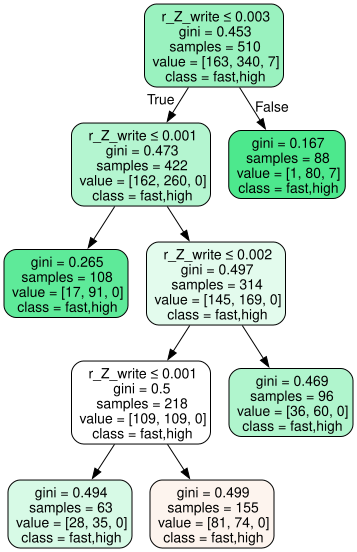

In [37]:
class_names =  my_space._get_cluster_labels()
dot_data = tree.export_graphviz(clf, out_file=None, feature_names=kp, class_names=class_names,
                                filled=True, rounded=True, special_characters=True)
graph = graphviz.Source(dot_data)

print(tree.export_text(cart_model.clf))
# pprint(tree.export_text(prunedTree))

graph

In [35]:
# my_space.import_dataset(X_test, y_test)
my_space.import_dataset(X_train, y_train)
print("  Computing robustness for all configurations...")
print(my_space.available_tradeoffs_)

df = my_space.compute_robustness_matrix()
df

  Computing robustness for all configurations...
Counter({'fast,average': 340, 'fast,high': 163, 'average,average': 7})


100%|██████████| 2/2 [00:00<00:00, 20.75it/s]

hw
sw


,hw,sw
"average,average",0.027778,0.0
"fast,average",0.325397,1.0
"fast,high",0.646825,0.0


In [36]:
warnings.filterwarnings('ignore')
my_space.import_dataset(X_train, y_train)

kp = filter_params

for qa_label in my_space.available_tradeoffs_.keys():
    my_space.import_dataset(X_train, y_train)
    n = my_space.available_tradeoffs_[qa_label]
    
    if n > 0:
        print("Checking (with PRIM) ----")
        property_to_check = my_space.get_property_box(qa_label)
        print("  ", qa_label, property_to_check)
        
        box1, prange, prim_model = my_space.run_prim(property_to_check, threshold=0.8, method='rhodium', key_parameters=kp, verbose=False)
        print("  New ranges:",  prange)

        my_space.import_dataset(X_test, y_test)
        my_space.adjust_parameters(prange)
        _ = my_space.discretize_outcomes(mins_maxs=MIN_MAX_RANGES)
        print("  Experiments:", my_space.experiments_df_.shape)

        print("  Computing robustness for all configurations...")
        df = my_space.compute_robustness_matrix()
        print(df)
        # plt.show()

Checking (with PRIM) ----
   fast,high {'response_time': (282.9, 1390.2999999999997), 'utilization': (0.7000000000000002, 1.1)}


  New ranges: {'r_Z_write': {'min': 0.0012270400481782001, 'max': 0.00206207482993195}}
  Experiments: (45, 12)
  Computing robustness for all configurations...


100%|██████████| 2/2 [00:00<00:00, 59.98it/s]


hw
sw
               hw   sw
fast,average  0.0  1.0
fast,high     1.0  0.0
Checking (with PRIM) ----
   fast,average {'response_time': (282.9, 1390.2999999999997), 'utilization': (0.30000000000000004, 0.7000000000000002)}
  New ranges: {}
  Experiments: (128, 12)
  Computing robustness for all configurations...


  0%|          | 0/2 [00:00<?, ?it/s]

hw
sw


100%|██████████| 2/2 [00:00<00:00, 33.73it/s]


                       hw   sw
average,average  0.032258  0.0
fast,average     0.306452  1.0
fast,high        0.661290  0.0
Checking (with PRIM) ----
   average,average {'response_time': (1390.2999999999997, 2497.7), 'utilization': (0.30000000000000004, 0.7000000000000002)}
  New ranges: {'r_Z_write': {'min': 0.0035098522167487, 'max': 0.005}}
  Experiments: (13, 12)
  Computing robustness for all configurations...


100%|██████████| 2/2 [00:00<00:00, 101.65it/s]

hw
sw
                  hw   sw
average,average  0.4  0.0
fast,average     0.6  1.0


In [37]:
my_space.import_dataset(X_train, y_train)

# CQRS.get_property_box('fast,high', label_values_df)
qa_label = 'fast,high' 
property_to_check = my_space.get_property_box(qa_label)
print(qa_label, property_to_check)

fast,high {'response_time': (282.9, 1390.2999999999997), 'utilization': (0.7000000000000002, 1.1)}


In [38]:
# my_space.experiments_df_.columns

In [39]:
# kp = filter_params
target_policy = 'hw'
# box1, prange, prim_model = my_space.run_prim(property_to_check, threshold=0.8, method='emaw', key_parameters=kp, policy=target_policy)
box1, prange, prim_model = my_space.run_prim(property_to_check, threshold=0.8, method='rhodium', key_parameters=kp)
prange

Instances satisfying property: False    347
True     163
Name: count, dtype: int64
Total instances: (510, 4)
Running PRIM ... rhodium


5 boxes


{'r_Z_write': {'min': 0.0012270400481782001, 'max': 0.00206207482993195}}

In [40]:
# EMAWorkbench
# fig = plt.figure(figsize=(24,12))
# box1.show_tradeoff(annotated=True)
# box1.show_pairs_scatter(upper='none', lower='scatter')
# box1.inspect(style='graph')

In [41]:
my_space.import_dataset(X_test, y_test)

In [42]:
my_space.experiments_df_

,scenario,N_read,N_write,r_Z_read,r_Z_write,C_DB_read,r_DB_read,C_DB_write,r_DB_write,C_DB,policy,model
0,133,90,10,0.1,0.001299,1,0.333333,1,0.022727,2,hw,cqrs
1,253,90,10,0.1,0.002041,1,0.142857,1,0.022727,2,hw,cqrs
2,86,90,10,0.1,0.005000,1,0.142857,1,0.027778,1,sw,cqrs
3,145,90,10,0.1,0.001149,1,0.333333,1,0.022727,2,hw,cqrs
4,271,90,10,0.1,0.002000,1,0.333333,1,0.027778,1,sw,cqrs
...,...,...,...,...,...,...,...,...,...,...,...,...
123,207,90,10,0.1,0.001351,1,0.333333,1,0.027778,2,hw,cqrs
124,100,90,10,0.1,0.003226,1,0.142857,1,0.027778,1,sw,cqrs
125,38,90,10,0.1,0.001639,1,0.142857,1,0.027778,2,hw,cqrs
126,238,90,10,0.1,0.001042,1,0.333333,1,0.027778,2,hw,cqrs


Reducing range for tradeoff: fast,high {'response_time': (282.9, 1390.2999999999997), 'utilization': (0.7000000000000002, 1.1)}
New ranges: {'r_Z_write': {'min': 0.0012270400481782001, 'max': 0.00206207482993195}}
Experiments: (45, 12)


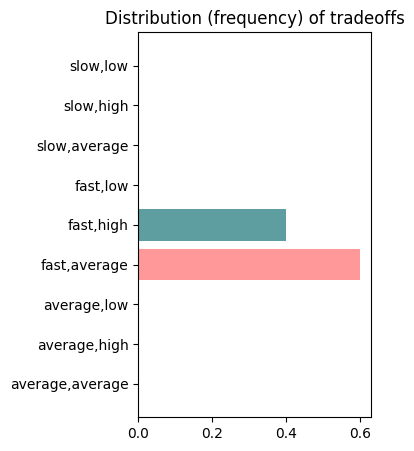

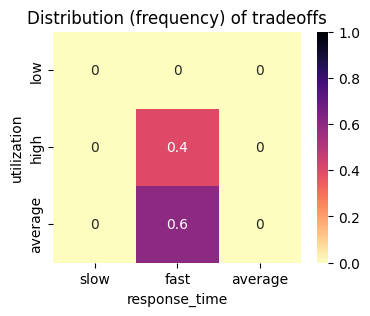

In [43]:
print("Reducing range for tradeoff:", qa_label, property_to_check)
print("New ranges:",  prange)

my_space.adjust_parameters(prange)
_ = my_space.discretize_outcomes(mins_maxs=MIN_MAX_RANGES)
print("Experiments:", my_space.experiments_df_.shape)

show_tradeoff_distribution(my_space, size=(3,5))
show_tradeoff_distribution(my_space, size=(4,3), in2D=True)

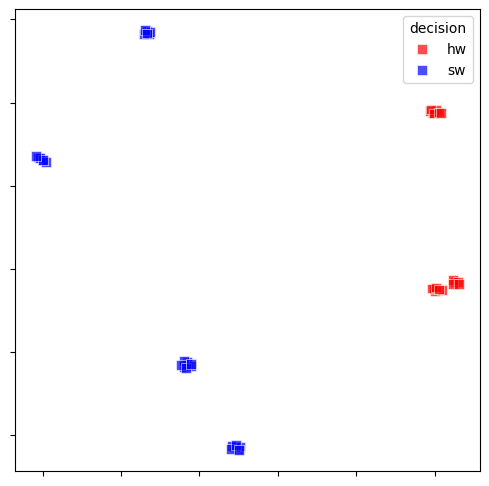

In [44]:
embeddings_df = show_configuration_space2D(my_space.experiments_df_, color_key=color_key, alpha=0.7)

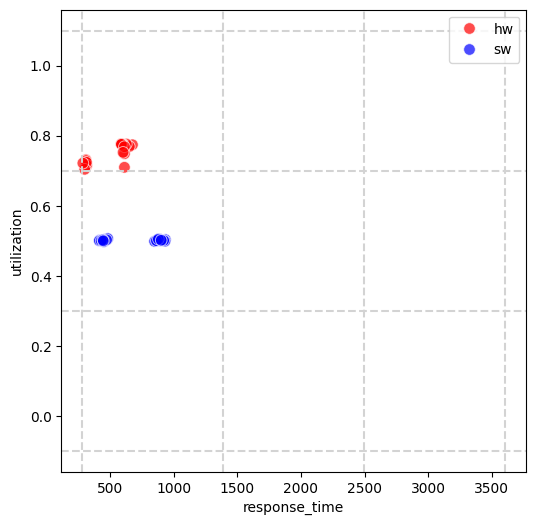

In [47]:
df = my_space.outcomes_df_.copy()
df['decision'] = my_space.experiments_df_['policy']
show_quality_attribute_space2D(df, MIN_MAX_RANGES, alpha=0.7, color_key=color_key)

In [46]:
print("Computing robustness for all configurations...")
main_dict = dict()
for exp in tqdm(my_space.get_configurations()):
    print(exp)
    main_dict[str(exp)] = dict()
    for qa in my_space.available_tradeoffs_.keys():
        main_dict[str(exp)][qa], _ = my_space.compute_robustness(exp, qa)
df = pd.DataFrame.from_dict(main_dict, orient='columns').sort_index()
df

Computing robustness for all configurations...


100%|██████████| 2/2 [00:00<00:00, 57.15it/s]

hw
sw


,hw,sw
"fast,average",0.0,1.0
"fast,high",1.0,0.0
